In [34]:
"""
Well Turbidity Analysis using Hough Circle Detection

This script:
1. Detects circular wells in 3x4 plate images.
2. Crops inner regions of each well.
3. Computes turbidity-related metrics:
      - Contrast (std deviation)
      - Laplacian variance (sharpness / blur)
      - Mean intensity
4. Aggregates results row-wise.
5. Outputs a Time x Row x Metric array.

Designed for bacterial growth / turbidity monitoring.
"""

!pip install opencv-python numpy matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import matplotlib.dates as mdates

In [36]:
# ==========================================================
# 1. WELL DETECTION
# ==========================================================

def detect_wells(image_path,
                 shrink_factor,
                 y_shift,
                 visualize,
                 debug,
                 expected_wells,
                 blur_kernel,
                 blur_sigma,
                 hough_dp,
                 hough_minDist,
                 hough_param1,
                 hough_param2,
                 hough_minRadius,
                 hough_maxRadius,
                 fallback_minDist,
                 fallback_param2,
                 fallback_minRadius,
                 fallback_maxRadius,
                 roi=None):
    """
    Detect circular wells using Hough Circle Transform.

    Workflow:
    1. Convert image to grayscale.
    2. Apply Gaussian blur to stabilize circle detection.
    3. Run HoughCircles with primary parameters.
    4. If number of detected wells != expected_wells,
       run fallback detection with stricter parameters.

    Parameters
    ----------
    shrink_factor : float
        Fraction of detected radius used for measurement.
        Smaller values exclude well wall reflections.

    debug : bool
        Shows intermediate preprocessing steps.

    visualize : bool
        Overlays detected circles on image.

    expected_wells : int
        Number of wells expected (e.g., 12 for 3x4 plate).

    Hough Parameters:
    ------------------
    hough_dp :
        Inverse resolution ratio for accumulator.
        Usually 1.2 works well.

    hough_minDist :
        Minimum allowed distance between circle centers.
        Increase if duplicate circles appear.

    hough_param1 :
        Higher Canny threshold (internal edge detection).

    hough_param2 :
        Accumulator threshold.
        Lower → more circles detected.
        Higher → stricter detection.

    hough_minRadius / hough_maxRadius :
        Allowed radius range.
        Tightening this reduces false detections.

    Fallback parameters:
        Used if first detection does not match expected_wells.
        Typically stricter to reduce false positives.
    """

    img = cv2.imread(image_path)

    # -------- ROI CROP --------
    if roi is not None:
        x_roi, y_roi, w_roi, h_roi = roi
        img_roi = img[y_roi:y_roi+h_roi, x_roi:x_roi+w_roi]
    else:
        img_roi = img

    if debug:
        if roi is not None:
            temp = img.copy()
            cv2.rectangle(temp, (x_roi, y_roi), (x_roi+w_roi, y_roi+h_roi), (0,255,255), 2)

            plt.figure(figsize=(6,5))
            plt.title("ROI Region")
            plt.imshow(cv2.cvtColor(temp, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.show()
        else:
            plt.figure(figsize=(6,5))
            plt.title("Original")
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.show()

    # Convert to grayscale
    gray = cv2.cvtColor(img_roi, cv2.COLOR_BGR2GRAY)

    if debug:
        plt.figure(figsize=(6,5))
        plt.title("Grayscale")
        plt.imshow(gray, cmap="gray")
        plt.axis("off")
        plt.show()

    # Gaussian smoothing improves stability of Hough detection
    if blur_kernel:
        blur = cv2.GaussianBlur(gray, blur_kernel, blur_sigma)
    else:
        blur = gray

    if debug:
        plt.figure(figsize=(6,5))
        plt.title("Gaussian Blur")
        plt.imshow(blur, cmap="gray")
        plt.axis("off")
        plt.show()

    # -------- Primary Detection --------
    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=hough_dp,
        minDist=hough_minDist,
        param1=hough_param1,
        param2=hough_param2,
        minRadius=hough_minRadius,
        maxRadius=hough_maxRadius
    )

    detected = len(circles[0]) if circles is not None else 0
    print(f"Initial circles detected: {detected}")

    # -------- Fallback Detection --------
    if detected != expected_wells:
        circles = cv2.HoughCircles(
            blur,
            cv2.HOUGH_GRADIENT,
            dp=hough_dp,
            minDist=fallback_minDist,
            param1=hough_param1,
            param2=fallback_param2,
            minRadius=fallback_minRadius,
            maxRadius=fallback_maxRadius
        )

    vis = img.copy()

    if circles is None:
        print("No circles detected")
        circles = []
    else:
        circles = np.round(circles[0]).astype(int)
        if roi is not None:
            circles[:, 0] += x_roi
            circles[:, 1] += y_roi
        circles = sorted(circles, key=lambda c: (c[1], c[0]))

        vis = img.copy()
        
        if visualize:
            # Draw ROI box
            if roi is not None:
                cv2.rectangle(vis, (x_roi, y_roi), (x_roi+w_roi, y_roi+h_roi), (0,255,255), 2)

            for (x, y, r) in circles:
                r_inner = int(r * shrink_factor)
                y_shift_px = int(r * y_shift)
                y_shifted = y + y_shift_px

                cv2.circle(vis, (x, y), r, (0,255,0), 2)
                cv2.circle(vis, (x, y_shifted), r_inner, (255,0,0), 2)
                cv2.circle(vis, (x, y_shifted), 3, (0,0,255), -1)

            print(f"Final detected circles: {len(circles)}")

            plt.figure(figsize=(8,6))
            plt.title("Final Detection (with ROI)")
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.show()

    return img, circles

In [37]:
# ==========================================================
# 2. WELL CROPPING
# ==========================================================

def crop_wells(img, circles, shrink_factor):
    """
    Crop inner square region of each detected well.

    shrink_factor controls how much of the detected radius
    is used for measurement.

    Smaller → avoids well wall reflections.
    Larger → includes more of liquid region.
    """
    wells = []

    for (x, y, r) in circles:
        r_inner = int(r * shrink_factor)
        crop = img[y-r_inner:y+r_inner, x-r_inner:x+r_inner]
        wells.append(crop)

    return wells

In [38]:
# ==========================================================
# 3. METRIC COMPUTATION
# ==========================================================

def well_metrics(well):
    """
    Compute turbidity-related metrics:

    contrast:
        Standard deviation of intensity.
        Lower as turbidity increases.

    laplacian_var:
        Sharpness measure (blur).
        Lower = more blur = more turbidity.

    mean_int:
        Average brightness.
    """

    gray = cv2.cvtColor(well, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    center = (w//2, h//2)
    radius = min(center)

    mask = np.zeros_like(gray)
    cv2.circle(mask, center, radius, 255, -1)

    pixels = gray[mask == 255]

    contrast = np.std(pixels)
    laplacian_var = cv2.Laplacian(pixels, cv2.CV_64F).var()
    mean_int = np.mean(pixels)

    return contrast, laplacian_var, mean_int



In [39]:
# ==========================================================
# 4. ROW AVERAGING
# ==========================================================

def row_averages(metrics, expected_wells, num_rows):
    """
    Compute row-wise averages.

    Parameters
    ----------
    metrics : ndarray
        Array of shape (expected_wells, num_metrics)

    expected_wells : int
        Total number of detected wells.

    num_rows : int
        Number of well rows in the plate layout.

    Notes
    -----
    Assumes wells are ordered row-major
    (left-to-right, top-to-bottom).
    """

    wells_per_row = expected_wells // num_rows

    row_data = []
    for i in range(0, expected_wells, wells_per_row):
        row = metrics[i:i+wells_per_row]
        row_data.append(np.mean(row, axis=0))

    return np.array(row_data)


In [40]:
# ==========================================================
# 5. Building the Final DataFrame
# ==========================================================

def build_dataframe(image_list, all_time_data, gravity_value, row_labels):
    
    timestamps = []
    
    for image_path in image_list:
        filename = os.path.basename(image_path)
        name_without_ext = os.path.splitext(filename)[0]
        time_str = name_without_ext.replace("image_", "")

        # Match your actual format
        dt = datetime.strptime(time_str, "%Y-%m-%d_%H_%M_%S")
        timestamps.append(dt)

    records = []

    for t_idx, timestamp in enumerate(timestamps):
        for row_idx in range(len(row_labels)):
            records.append({
                "Time": timestamp,
                "Sample": row_labels[row_idx],
                "Gravity": gravity_value,
                "Contrast": all_time_data[t_idx, row_idx, 0],
                "Sharpness": all_time_data[t_idx, row_idx, 1],
                "Mean_Intensity": all_time_data[t_idx, row_idx, 2],
            })

    return pd.DataFrame(records)

In [41]:
# =========================
# USER CONFIGURATION
# =========================

FOLDER_PATH = "payload"

EXPECTED_WELLS = 4      # Change if plate layout changes
NUM_ROWS = 2             # Number of rows in the plate (e.g., 3 for 3x4 layout)

# --- Crop ---
SHRINK_FACTOR = 0.3      # Smaller excludes wall reflections
Y_SHIFT = 0           # Shift down to avoid reflections at top edge

# --- Debug / Visualization ---
DEBUG = False            # Show intermediate steps for troubleshooting
VISUALIZE = False         # Show detected circles on images

# --- Blur ---
BLUR_KERNEL = None      # Larger → smoother → fewer false edges
BLUR_SIGMA = 0           # Controls smoothing strength

# --- Primary Hough ---
HOUGH_DP = 1.2
HOUGH_MIN_DIST = 100     # Increase if duplicate detections
HOUGH_PARAM1 = 100
HOUGH_PARAM2 = 35       # Lower → more circles detected
HOUGH_MIN_RADIUS = 70
HOUGH_MAX_RADIUS = 110

# --- Fallback Hough ---
FALLBACK_MIN_DIST = 100
FALLBACK_PARAM2 = 47     # Stricter threshold
FALLBACK_MIN_RADIUS = 80
FALLBACK_MAX_RADIUS = 100



# ==========================================================
# MAIN EXECUTION PIPELINE
# ==========================================================
"""
Main Processing Loop

For each image in FOLDER_PATH:

1. Detect circular wells using Hough transform.
2. Crop inner region of each well.
3. Compute turbidity-related metrics:
       - Contrast (intensity standard deviation)
       - Laplacian variance (sharpness / blur proxy)
       - Mean intensity
4. Average wells row-wise.
5. Store results as:

    all_time_data → shape (Time, Row, Metric)

Where:
    Time   = number of images processed
    Row    = number of well rows (e.g., 3)
    Metric = 3 values per row:
             [Contrast, Laplacian, Mean]

Final output shape:
    (Number_of_images, 3, 3)
"""

# Collect all image paths from the selected folder
image_list_earth = sorted([
    os.path.join(FOLDER_PATH, f)
    for f in os.listdir(FOLDER_PATH)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

# This will store data across time points
all_time_data_earth = []

for image_path in image_list_earth:
    print(f"\nProcessing: {image_path}")

    # ---------------------------
    # 1. Detect Wells
    # ---------------------------
    ROI = (175, 10, 375, 375)  # Manually defined region of interest (x, y, width, height)

    img, circles = detect_wells(
        image_path,
        SHRINK_FACTOR,
        Y_SHIFT,
        VISUALIZE,
        DEBUG,
        EXPECTED_WELLS,
        BLUR_KERNEL,
        BLUR_SIGMA,
        HOUGH_DP,
        HOUGH_MIN_DIST,
        HOUGH_PARAM1,
        HOUGH_PARAM2,
        HOUGH_MIN_RADIUS,
        HOUGH_MAX_RADIUS,
        FALLBACK_MIN_DIST,
        FALLBACK_PARAM2,
        FALLBACK_MIN_RADIUS,
        FALLBACK_MAX_RADIUS,
        roi=ROI   # 👈 pass here
    )

    # ---------------------------
    # 2. Crop Wells
    # ---------------------------
    wells = crop_wells(img, circles, SHRINK_FACTOR)

    # ---------------------------
    # 3. Compute Metrics
    # ---------------------------
    metrics = np.array([well_metrics(w) for w in wells])

    # ---------------------------
    # 4. Row Averaging
    # ---------------------------
    row_data = row_averages(metrics, EXPECTED_WELLS, NUM_ROWS)

    # Store results for this time point
    print(row_data.shape)
    all_time_data_earth.append(row_data)
    # break

# Convert list → numpy array
all_time_data_earth = np.array(all_time_data_earth)

# ---------------------------
# Final Output Summary
# ---------------------------
print("\n==============================")
print("Final Output Summary")
print("==============================")

print(f"Data dimensions (# of Images x Well Rows x Measurements): {all_time_data_earth.shape}")
print()

print(f"\nRow-wise averages (Contrast, Sharpness, Mean Intensity): \n{all_time_data_earth}\n")


Processing: payload\image_2025-08-07_17_31_02.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_18_01_02.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_18_31_02.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_19_01_02.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_19_31_02.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_20_01_02.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_20_31_02.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_21_01_02.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_21_31_03.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_22_01_03.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_22_31_03.jpg
Initial circles detected: 4
(2, 3)

Processing: payload\image_2025-08-07_23_01_03.jpg
Ini

In [42]:
# -------------------------------
# 6. Extract timestamps
# -------------------------------

def extract_timestamps(image_list):
    timestamps = []
    for image_path in image_list:
        filename = os.path.basename(image_path)
        name_without_ext = os.path.splitext(filename)[0]

        # Remove prefix "image_"
        time_str = name_without_ext.replace("image_", "")

        # Match your actual format
        dt = datetime.strptime(time_str, "%Y-%m-%d_%H_%M_%S")

        timestamps.append(dt)
    return np.array(timestamps)

timestamps_earth = extract_timestamps(image_list_earth)
# timestamps_mars = extract_timestamps(image_list_mars)

metric_names = ["Contrast", "Sharpness", "Mean Intensity"]
row_labels = ["E. coli", "Shewanella"]

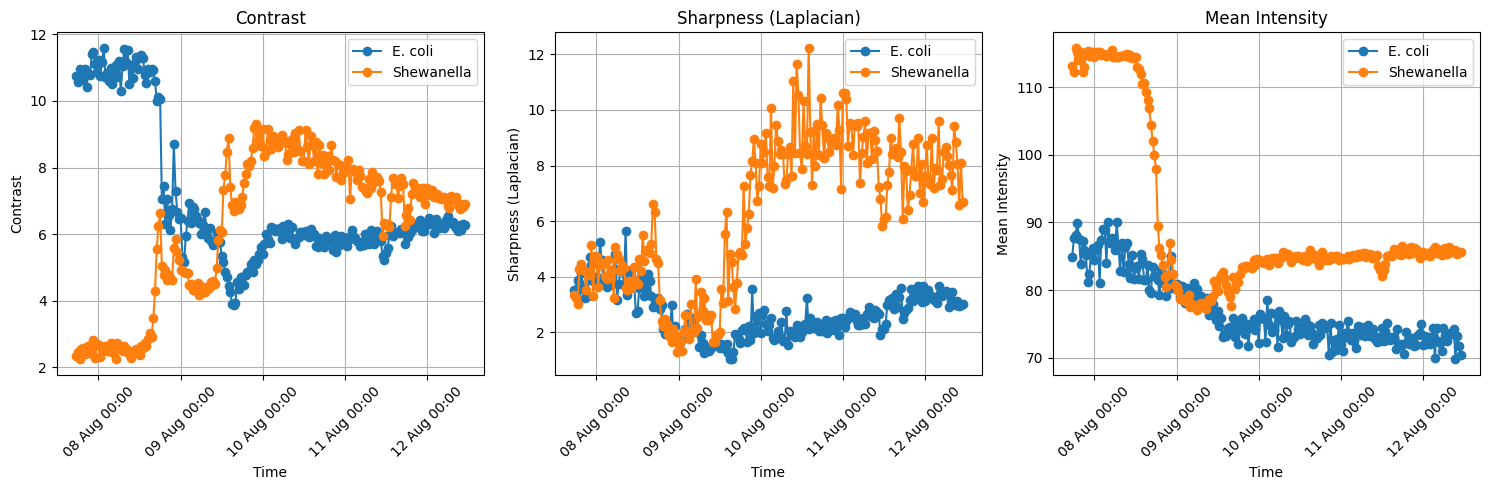

In [43]:
# Extract datetime from filenames
timestamps = []

for image_path in image_list_earth:
    filename = os.path.basename(image_path)
    name_without_ext = os.path.splitext(filename)[0]
    
    time_str = name_without_ext.replace("image_", "")
    dt = datetime.strptime(time_str, "%Y-%m-%d_%H_%M_%S")
    timestamps.append(dt)

timestamps = np.array(timestamps)

metric_names = ["Contrast", "Sharpness (Laplacian)", "Mean Intensity"]

# Custom row labels
row_labels = ["E. coli", "Shewanella"]

plt.figure(figsize=(15, 5))

for metric_idx in range(3):
    ax = plt.subplot(1, 3, metric_idx + 1)

    for row in range(all_time_data_earth.shape[1]):
        ax.plot(    
            timestamps,
            all_time_data_earth[:, row, metric_idx],
            marker='o',
            label=row_labels[row]   # <-- changed here
        )

    ax.set_title(metric_names[metric_idx])
    ax.set_xlabel("Time")
    ax.set_ylabel(metric_names[metric_idx])

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))

    plt.xticks(rotation=45)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [44]:
row_labels = ["E. coli", "Shewanella"]

df_earth = build_dataframe(
    image_list_earth,
    all_time_data_earth,
    gravity_value=1.0,
    row_labels=row_labels
)

df_combined = pd.concat([df_earth], ignore_index=True)

df_combined = df_combined.sort_values(["Gravity", "Time"])

print(df_combined.to_string(index=False))

               Time     Sample  Gravity  Contrast  Sharpness  Mean_Intensity
2025-08-07 17:31:02    E. coli      1.0 10.742025   3.498861       84.960645
2025-08-07 17:31:02 Shewanella      1.0  2.355418   3.343040      113.164977
2025-08-07 18:01:02    E. coli      1.0 10.572017   3.339936       87.751858
2025-08-07 18:01:02 Shewanella      1.0  2.448357   3.215438      112.291688
2025-08-07 18:31:02    E. coli      1.0 10.969913   3.867112       88.165550
2025-08-07 18:31:02 Shewanella      1.0  2.243711   2.993873      115.791730
2025-08-07 19:01:02    E. coli      1.0 10.625189   3.769402       89.966778
2025-08-07 19:01:02 Shewanella      1.0  2.556916   4.277725      115.205757
2025-08-07 19:31:02    E. coli      1.0 10.760385   4.138386       87.531821
2025-08-07 19:31:02 Shewanella      1.0  2.588885   4.449503      114.016989
2025-08-07 20:01:02    E. coli      1.0 10.973008   3.545246       83.900650
2025-08-07 20:01:02 Shewanella      1.0  2.400246   4.234351      115.200954